# 🎤 IPL: 10 Things You Probably Didn't Know

*A data-driven warm-up to break the ice.*

Ten counter-intuitive, fan-friendly stats — each one starts with a question for the audience, then reveals the answer with a chart. Run cells one at a time during your session.

**Prerequisite:** `get_ipl_data.py` has been run; CSVs in `ipl_data/`.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '.'
deliveries = pd.read_csv(f'{DATA_DIR}/deliveries_features.csv')
matches    = pd.read_csv(f'{DATA_DIR}/matches.csv')
deliveries['match_id'] = deliveries['match_id'].astype(str)
matches['match_id']    = matches['match_id'].astype(str)

def normalize_season(s):
    if pd.isna(s): return None
    s = str(s)
    if '/' in s: return int(s.split('/')[0])
    try: return int(s)
    except ValueError: return None

matches['season_year']    = matches['season'].apply(normalize_season)
deliveries['season_year'] = deliveries['season'].apply(normalize_season)

print(f'🏏 Loaded {len(matches):,} matches and {len(deliveries):,} balls')
print(f'   Spanning {int(deliveries["season_year"].min())} to {int(deliveries["season_year"].max())}')

🏏 Loaded 1,235 matches and 293,764 balls
   Spanning 2007 to 2026


## 🎤 Fact #1 — *The Toss Trap*

> **"Ask the audience: Out of every 100 IPL matches, how many does the toss winner go on to win?"**
>
> *Most people guess 60-70%. Let's see...*

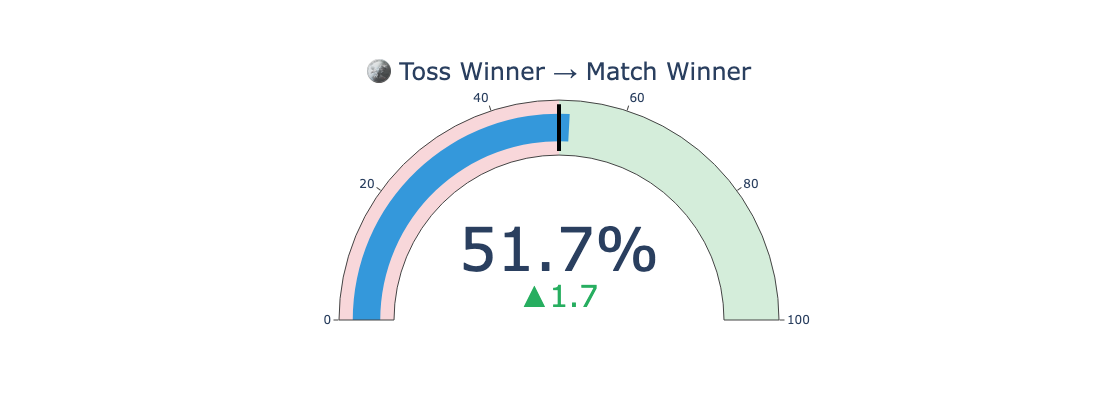


💡 Reality check: 51.7% — basically a coin flip.
   Winning the toss helps almost nothing in the long run.


In [2]:
toss_data = matches.dropna(subset=['toss_winner', 'winner']).copy()
toss_winner_win_rate = (toss_data['toss_winner'] == toss_data['winner']).mean() * 100

fig = go.Figure(go.Indicator(
    mode='gauge+number+delta',
    value=toss_winner_win_rate,
    number={'suffix': '%', 'font': {'size': 60}},
    delta={'reference': 50, 'increasing': {'color': '#27ae60'},
           'decreasing': {'color': '#e74c3c'}},
    gauge={
        'axis': {'range': [0, 100]},
        'bar': {'color': '#3498db'},
        'steps': [{'range': [0, 50], 'color': '#f8d7da'},
                  {'range': [50, 100], 'color': '#d4edda'}],
        'threshold': {'line': {'color': 'black', 'width': 4}, 'value': 50}
    },
    title={'text': '🪙 Toss Winner → Match Winner', 'font': {'size': 24}}
))
fig.update_layout(height=400)
fig.show()

print(f'\n💡 Reality check: {toss_winner_win_rate:.1f}% — basically a coin flip.')
print(f'   Winning the toss helps almost nothing in the long run.')

## 🎤 Fact #2 — *The 200 Club Has Exploded*

> **"200 was once considered an unbeatable score. How many 200+ totals have we seen in the LAST season compared to the FIRST season?"**

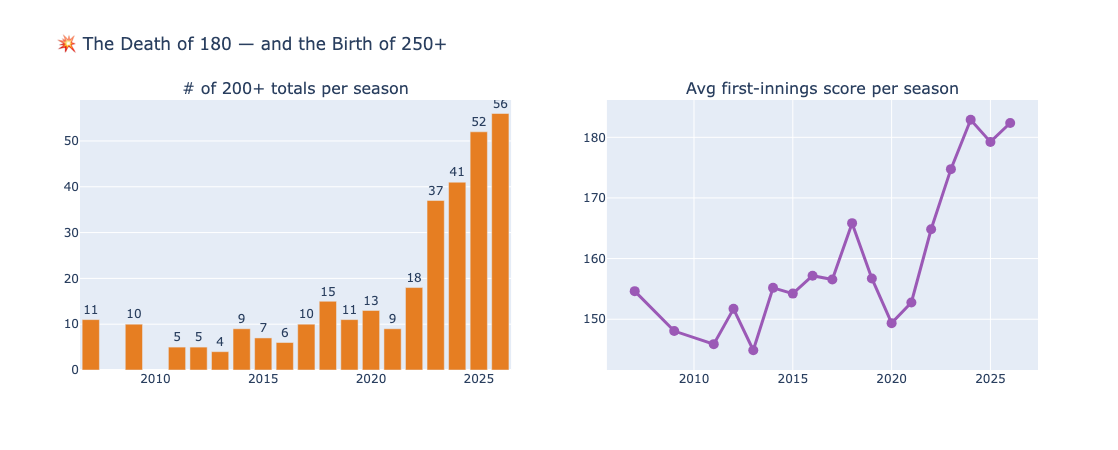


💡 In 2007: just 11 totals of 200+. In 2026: 56.
   Highest team total ever in this dataset: 287 runs.


In [3]:
innings_totals = (deliveries.groupby(['match_id', 'innings', 'season_year'])['total_runs']
                  .sum().reset_index().rename(columns={'total_runs': 'inn_total'}))

by_season = (innings_totals.groupby('season_year')
             .agg(innings_count=('inn_total', 'count'),
                  count_200_plus=('inn_total', lambda x: (x >= 200).sum()),
                  max_total=('inn_total', 'max'),
                  avg_total=('inn_total', 'mean'))
             .reset_index())
by_season['pct_200_plus'] = (by_season['count_200_plus'] / by_season['innings_count'] * 100).round(1)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('# of 200+ totals per season',
                                    'Avg first-innings score per season'))

fig.add_trace(go.Bar(x=by_season['season_year'], y=by_season['count_200_plus'],
                     text=by_season['count_200_plus'], textposition='outside',
                     marker_color='#e67e22', name='200+ totals'),
              row=1, col=1)

fig.add_trace(go.Scatter(x=by_season['season_year'], y=by_season['avg_total'],
                          mode='lines+markers', marker=dict(size=10, color='#9b59b6'),
                          line=dict(width=3), name='Avg total'),
              row=1, col=2)

fig.update_layout(height=450, showlegend=False,
                  title='💥 The Death of 180 — and the Birth of 250+')
fig.show()

first_season = by_season.iloc[0]
last_season  = by_season.iloc[-1]
print(f'\n💡 In {int(first_season["season_year"])}: just {int(first_season["count_200_plus"])} '
      f'totals of 200+. In {int(last_season["season_year"])}: {int(last_season["count_200_plus"])}.')
print(f'   Highest team total ever in this dataset: {int(by_season["max_total"].max())} runs.')

## 🎤 Fact #3 — *The Most Dangerous Over*

> **"Which over of the 20 produces the most runs per ball? Most people say the 20th. Wrong."**

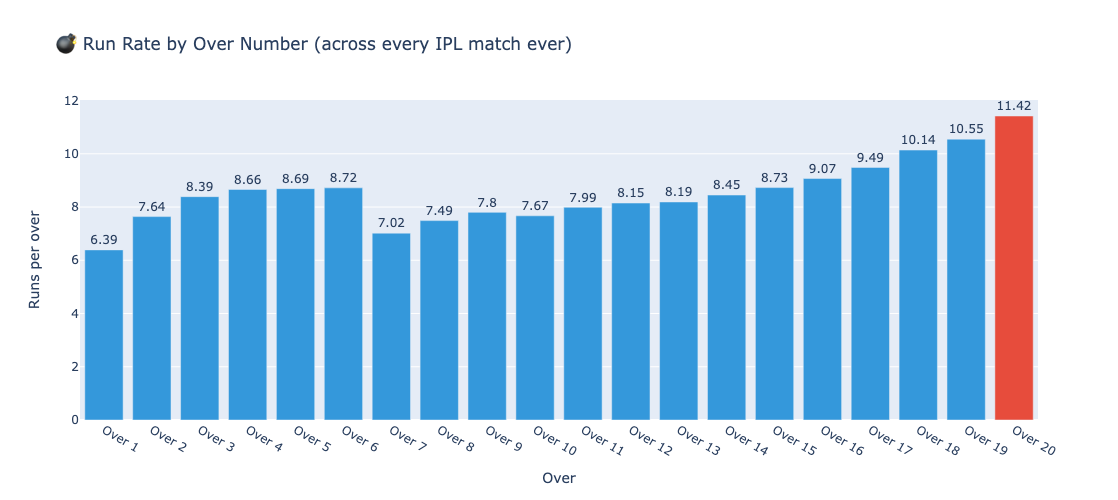


💡 The MOST dangerous over is Over 20 with 11.42 runs per over on average.
   Reason: set batters, fielders spread, bowlers running on fumes.


In [4]:
over_stats = (deliveries.groupby('over_num')
              .agg(total_runs=('total_runs', 'sum'),
                   balls=('is_legal_delivery', 'sum'),
                   wickets=('is_wicket', 'sum'))
              .reset_index())
over_stats['runs_per_ball'] = over_stats['total_runs'] / over_stats['balls']
over_stats['run_rate']      = (over_stats['runs_per_ball'] * 6).round(2)
over_stats = over_stats[over_stats['over_num'] < 20]

colors = ['#3498db'] * len(over_stats)
top_idx = over_stats['run_rate'].idxmax()
colors[top_idx] = '#e74c3c'

fig = go.Figure()
fig.add_trace(go.Bar(
    x=[f'Over {i+1}' for i in over_stats['over_num']],
    y=over_stats['run_rate'],
    text=over_stats['run_rate'],
    textposition='outside',
    marker_color=colors,
    hovertemplate='%{x}<br>Run rate: %{y}<br>Balls: %{customdata}<extra></extra>',
    customdata=over_stats['balls']
))
fig.update_layout(
    title='💣 Run Rate by Over Number (across every IPL match ever)',
    xaxis_title='Over', yaxis_title='Runs per over',
    height=500, showlegend=False)
fig.show()

best_over = over_stats.iloc[top_idx]
print(f'\n💡 The MOST dangerous over is Over {int(best_over["over_num"])+1} '
      f'with {best_over["run_rate"]} runs per over on average.')
print(f'   Reason: set batters, fielders spread, bowlers running on fumes.')

## 🎤 Fact #4 — *Boundary or Wicket: Which Happens More Often?*

> **"What's more common in T20 cricket: a boundary (4 or 6) or a dot ball?"**
>
> *Hint: people massively overestimate how many boundaries there are.*

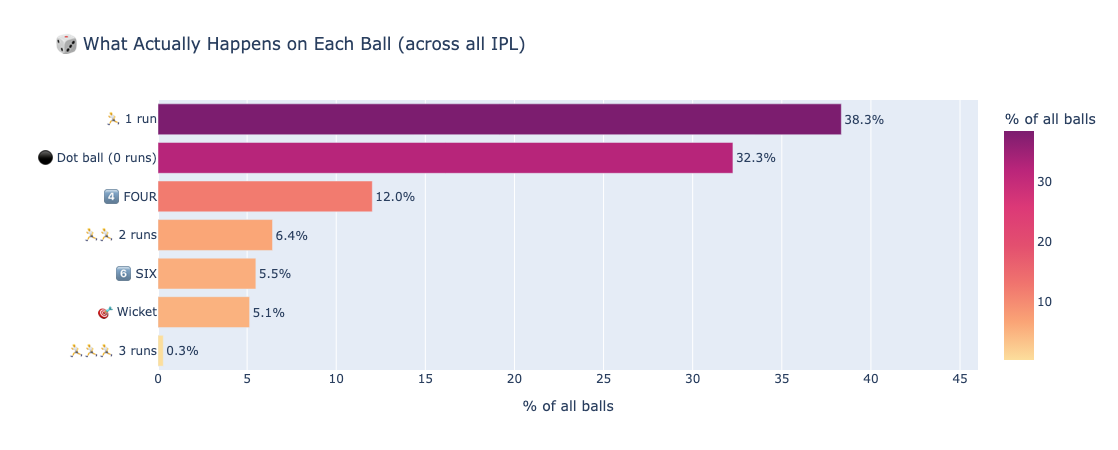


💡 Dot balls happen 32.3% of the time.
   Fours: 12.0%, Sixes: 5.5% — only ~18% of balls end in a boundary!


In [5]:
legal_balls = deliveries[deliveries['is_legal_delivery'] == 1].copy()
total = len(legal_balls)

outcomes = {
    '⚫ Dot ball (0 runs)': (legal_balls['runs_off_bat'] == 0).sum() - legal_balls['is_wicket'].sum(),
    '🏃 1 run':              (legal_balls['runs_off_bat'] == 1).sum(),
    '🏃🏃 2 runs':           (legal_balls['runs_off_bat'] == 2).sum(),
    '🏃🏃🏃 3 runs':         (legal_balls['runs_off_bat'] == 3).sum(),
    '4️⃣ FOUR':              legal_balls['is_four'].sum(),
    '6️⃣ SIX':               legal_balls['is_six'].sum(),
    '🎯 Wicket':             legal_balls['is_wicket'].sum(),
}

outcome_df = pd.DataFrame([
    {'outcome': k, 'count': v, 'pct': v/total*100} for k, v in outcomes.items()
]).sort_values('count', ascending=True)

fig = px.bar(outcome_df, x='pct', y='outcome', orientation='h',
             text=outcome_df['pct'].round(1).astype(str) + '%',
             color='pct', color_continuous_scale='Sunsetdark',
             title='🎲 What Actually Happens on Each Ball (across all IPL)',
             labels={'pct': '% of all balls', 'outcome': ''})
fig.update_traces(textposition='outside')
fig.update_layout(height=450, showlegend=False, xaxis_range=[0, max(outcome_df['pct'])*1.2])
fig.show()

dot_pct = outcomes['⚫ Dot ball (0 runs)'] / total * 100
four_pct = outcomes['4️⃣ FOUR'] / total * 100
six_pct = outcomes['6️⃣ SIX'] / total * 100
print(f'\n💡 Dot balls happen {dot_pct:.1f}% of the time.')
print(f'   Fours: {four_pct:.1f}%, Sixes: {six_pct:.1f}% — only ~{four_pct+six_pct:.0f}% '
      f'of balls end in a boundary!')

## 🎤 Fact #5 — *The 100-Crore Question: Bat First or Chase?*

> **"Conventional wisdom says 'win the toss, bowl second'. Is it actually true?"**

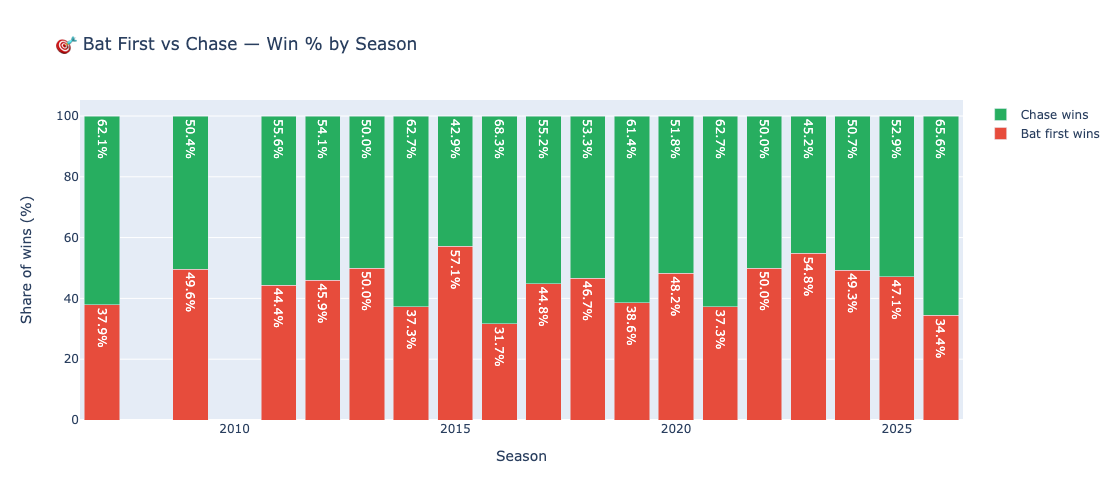


💡 Across all IPL history, teams batting first win 45.2% of matches.
   So chasing wins ~55% — but it has varied wildly by season.
   Recent trend: dew, smaller boundaries, better batters — chasers have the edge.


In [6]:
m = matches.dropna(subset=['toss_decision', 'team1', 'team2', 'winner', 'toss_winner']).copy()
m['bat_first_team'] = np.where(
    m['toss_decision'] == 'bat',
    m['toss_winner'],
    np.where(m['toss_winner'] == m['team1'], m['team2'], m['team1'])
)
m['bat_first_won'] = (m['bat_first_team'] == m['winner']).astype(int)

by_season = m.groupby('season_year').agg(
    bat_first_wins=('bat_first_won', 'sum'),
    total=('match_id', 'count')
).reset_index()
by_season['bat_first_pct'] = (by_season['bat_first_wins'] / by_season['total'] * 100).round(1)
by_season['chase_pct']     = 100 - by_season['bat_first_pct']

fig = go.Figure()
fig.add_trace(go.Bar(name='Bat first wins',
                     x=by_season['season_year'], y=by_season['bat_first_pct'],
                     marker_color='#e74c3c',
                     text=by_season['bat_first_pct'].astype(str) + '%',
                     textposition='inside'))
fig.add_trace(go.Bar(name='Chase wins',
                     x=by_season['season_year'], y=by_season['chase_pct'],
                     marker_color='#27ae60',
                     text=by_season['chase_pct'].astype(str) + '%',
                     textposition='inside'))
fig.update_layout(barmode='stack',
                  title='🎯 Bat First vs Chase — Win % by Season',
                  xaxis_title='Season', yaxis_title='Share of wins (%)',
                  height=500)
fig.show()

overall_bat = m['bat_first_won'].mean() * 100
print(f'\n💡 Across all IPL history, teams batting first win {overall_bat:.1f}% of matches.')
print(f'   So chasing wins ~{100-overall_bat:.0f}% — but it has varied wildly by season.')
print(f'   Recent trend: dew, smaller boundaries, better batters — chasers have the edge.')

## 🎤 Fact #6 — *The Ultimate Six-Hitter*

> **"Who has hit the most sixes in IPL history? Most people guess Dhoni or Kohli. Both wrong."**

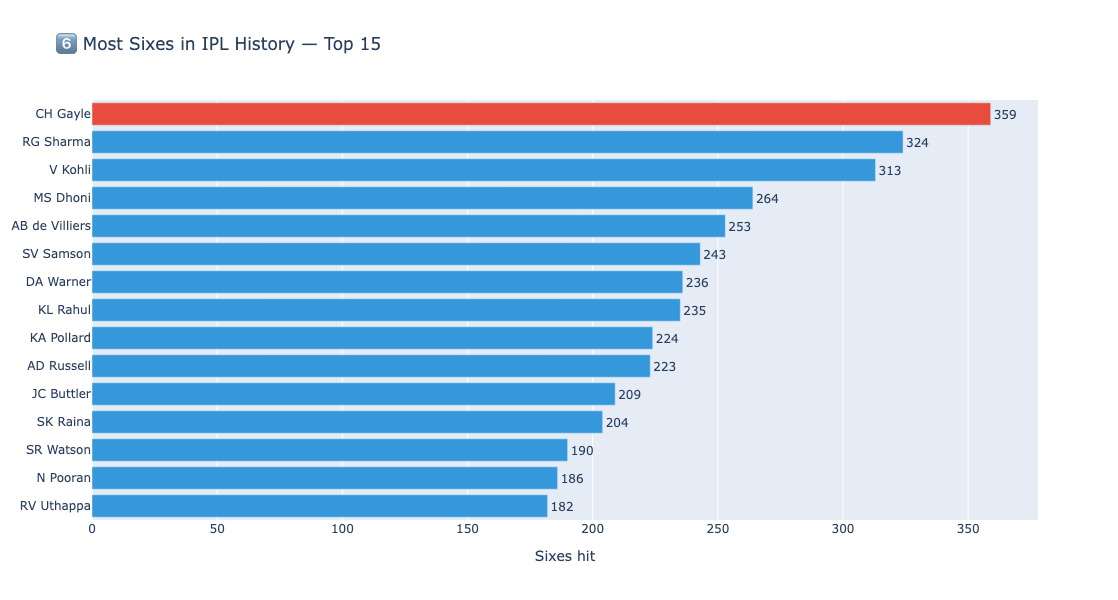


💡 The Six King: CH Gayle with 359 sixes.
   That's roughly 2154 runs just from sixes.


In [7]:
top_sixes = (deliveries.dropna(subset=['striker'])
             .groupby('striker')['is_six'].sum()
             .sort_values(ascending=False).head(15).reset_index())
top_sixes.columns = ['player', 'total_sixes']

# Build colors - top 1 special, others gradient
colors = ['#e74c3c'] + ['#3498db'] * (len(top_sixes) - 1)

fig = go.Figure(go.Bar(
    x=top_sixes['total_sixes'],
    y=top_sixes['player'],
    orientation='h',
    text=top_sixes['total_sixes'],
    textposition='outside',
    marker_color=colors
))
fig.update_layout(
    title='6️⃣ Most Sixes in IPL History — Top 15',
    height=600,
    yaxis={'categoryorder': 'total ascending'},
    xaxis_title='Sixes hit'
)
fig.show()

champ = top_sixes.iloc[0]
print(f'\n💡 The Six King: {champ["player"]} with {int(champ["total_sixes"])} sixes.')
print(f'   That\'s roughly {int(champ["total_sixes"])*6} runs just from sixes.')

## 🎤 Fact #7 — *The Wicket-Taking Conundrum*

> **"What is the MOST common way batters get out in T20?"**
>
> *Options: Bowled, Caught, LBW, Run-out, Stumped?*

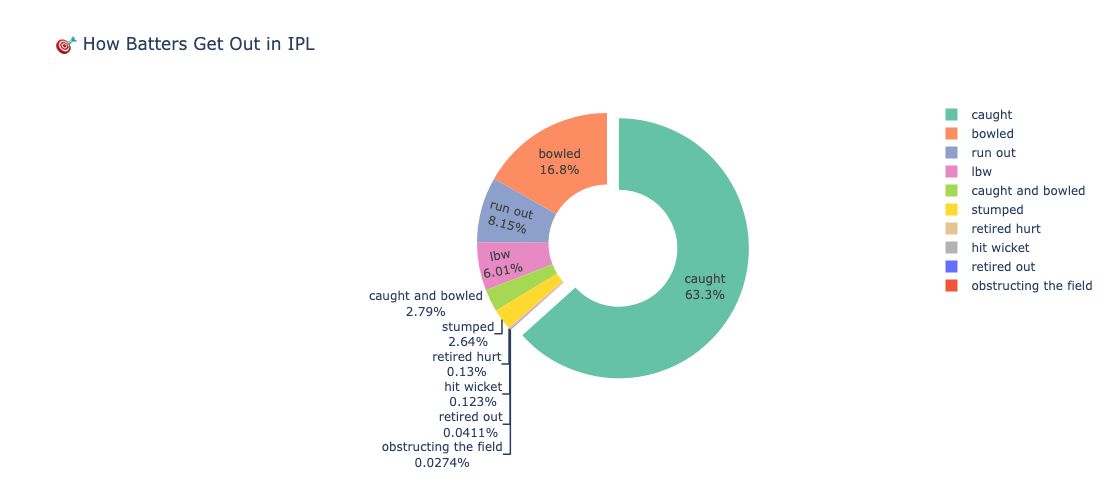


💡 CAUGHT accounts for 63.3% of all dismissals.
   The classic skill of finding the edge or beating the bat is still king.
   LBW is surprisingly rare in T20 — batters charge down too often.


In [8]:
wickets = (deliveries.dropna(subset=['wicket_type'])
           .groupby('wicket_type').size().reset_index(name='count')
           .sort_values('count', ascending=False))
wickets['pct'] = (wickets['count'] / wickets['count'].sum() * 100).round(1)

fig = go.Figure(go.Pie(
    labels=wickets['wicket_type'],
    values=wickets['count'],
    hole=0.45,
    textinfo='label+percent',
    pull=[0.1 if i == 0 else 0 for i in range(len(wickets))],
    marker=dict(colors=px.colors.qualitative.Set2),
    hovertemplate='%{label}: %{value} wickets (%{percent})<extra></extra>'
))
fig.update_layout(title='🎯 How Batters Get Out in IPL', height=500)
fig.show()

top_wkt = wickets.iloc[0]
print(f'\n💡 {top_wkt["wicket_type"].upper()} accounts for {top_wkt["pct"]}% of all dismissals.')
print(f'   The classic skill of finding the edge or beating the bat is still king.')
print(f'   LBW is surprisingly rare in T20 — batters charge down too often.')

## 🎤 Fact #8 — *The Underdog Story*

> **"What is the LOWEST first-innings score that's still been successfully defended?"**
>
> *(Hint: the bowlers absolutely cooked.)*

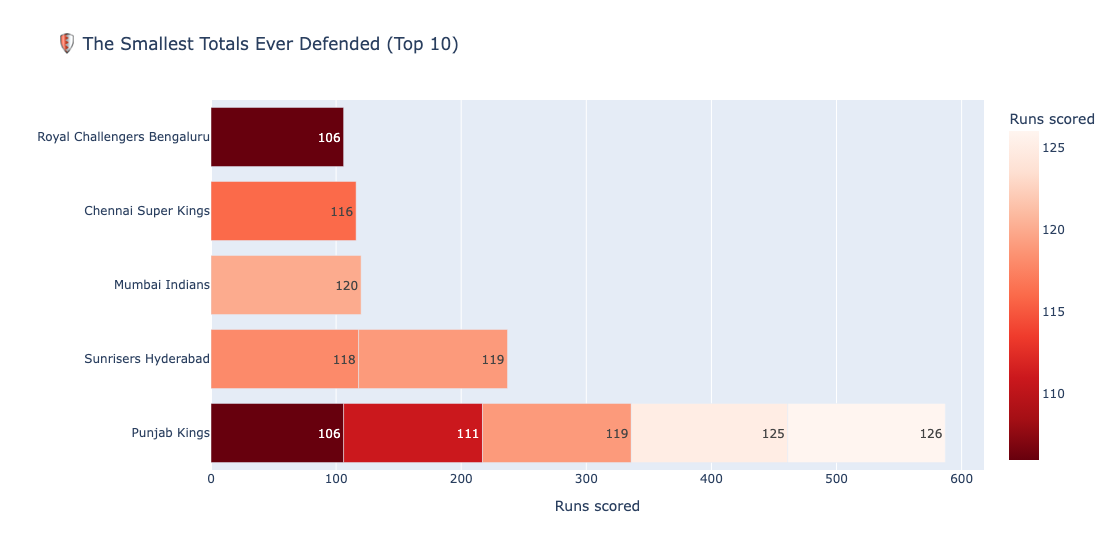


💡 The lowest defended total: 106 by Punjab Kings in 2015
   Venue: Punjab Cricket Association Stadium, Mohali
   Imagine: they scored that low and still won. Bowlers > batters that day.


In [9]:
# First innings total per match + winner
first_inn = (deliveries[deliveries['innings'] == 1]
             .groupby('match_id')
             .agg(first_inn_total=('total_runs', 'sum'),
                  batting_team=('batting_team', 'first'))
             .reset_index())
first_inn = first_inn.merge(matches[['match_id', 'winner', 'season_year', 'venue']],
                            on='match_id', how='left')
first_inn['bat_first_won'] = first_inn['batting_team'] == first_inn['winner']

# Lowest defended totals
defended = first_inn[first_inn['bat_first_won']].sort_values('first_inn_total').head(10)

fig = px.bar(defended, x='first_inn_total', y='batting_team',
             orientation='h', text='first_inn_total',
             color='first_inn_total', color_continuous_scale='Reds_r',
             hover_data={'season_year': True, 'venue': True},
             title='🛡️ The Smallest Totals Ever Defended (Top 10)',
             labels={'first_inn_total': 'Runs scored', 'batting_team': ''})
fig.update_layout(height=550, yaxis={'categoryorder': 'total descending'}, showlegend=False)
fig.show()

lowest = defended.iloc[0]
print(f'\n💡 The lowest defended total: {int(lowest["first_inn_total"])} by '
      f'{lowest["batting_team"]} in {int(lowest["season_year"])}')
print(f'   Venue: {lowest["venue"]}')
print(f'   Imagine: they scored that low and still won. Bowlers > batters that day.')

## 🎤 Fact #9 — *The Powerplay Premium*

> **"How much of a team's total comes from just the FIRST 6 overs (the powerplay)?"**
>
> *The powerplay is just 30% of the innings (6 of 20 overs). But how much of the runs?*

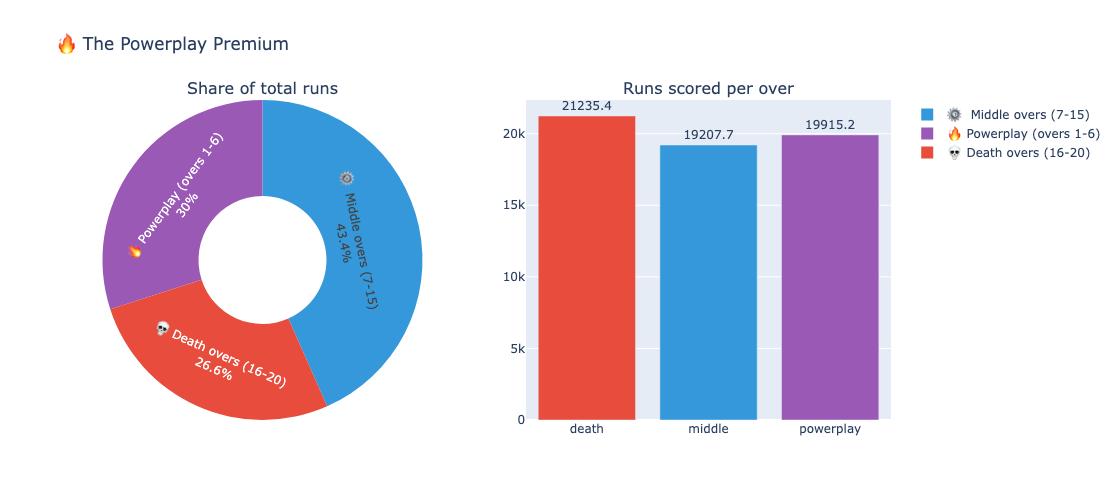


💡 Powerplay (30% of overs) gives ~30.0% of total runs.
   But check this — death overs (just 25% of overs) hand back 26.6%, packing the highest run-per-over rate.


In [10]:
phase_runs = (deliveries.groupby('phase', observed=True)['total_runs']
              .sum().reset_index())
total_runs = phase_runs['total_runs'].sum()
phase_runs['pct']   = (phase_runs['total_runs'] / total_runs * 100).round(1)
phase_runs['overs'] = phase_runs['phase'].map({'powerplay': 6, 'middle': 9, 'death': 5})
phase_runs['overs_pct'] = (phase_runs['overs'] / 20 * 100).round(0)
phase_runs['emoji'] = phase_runs['phase'].map({
    'powerplay': '🔥 Powerplay (overs 1-6)',
    'middle':    '⚙️  Middle overs (7-15)',
    'death':     '💀 Death overs (16-20)'
})

fig = make_subplots(rows=1, cols=2, specs=[[{'type':'pie'}, {'type':'bar'}]],
                    subplot_titles=('Share of total runs', 'Runs scored per over'))
fig.add_trace(go.Pie(labels=phase_runs['emoji'], values=phase_runs['total_runs'],
                     hole=0.4, textinfo='label+percent',
                     marker=dict(colors=['#e74c3c', '#3498db', '#9b59b6'])),
              row=1, col=1)
fig.add_trace(go.Bar(x=phase_runs['phase'],
                     y=(phase_runs['total_runs'] / phase_runs['overs']).round(1),
                     text=(phase_runs['total_runs'] / phase_runs['overs']).round(1),
                     textposition='outside',
                     marker_color=['#e74c3c', '#3498db', '#9b59b6'],
                     showlegend=False),
              row=1, col=2)
fig.update_layout(height=500, title='🔥 The Powerplay Premium')
fig.show()

pp = phase_runs[phase_runs['phase'] == 'powerplay'].iloc[0]
death = phase_runs[phase_runs['phase'] == 'death'].iloc[0]
print(f'\n💡 Powerplay (30% of overs) gives ~{pp["pct"]}% of total runs.')
print(f'   But check this — death overs (just 25% of overs) hand back '
      f'{death["pct"]}%, packing the highest run-per-over rate.')

## 🎤 Fact #10 — *Cricket's Most Boring Truth*

> **"What single delivery type has been bowled MORE than any other? Yorker? Bouncer? Slower ball?"**
>
> *Actually let's flip it — what's the MOST and LEAST scoring shot range a batter plays?*

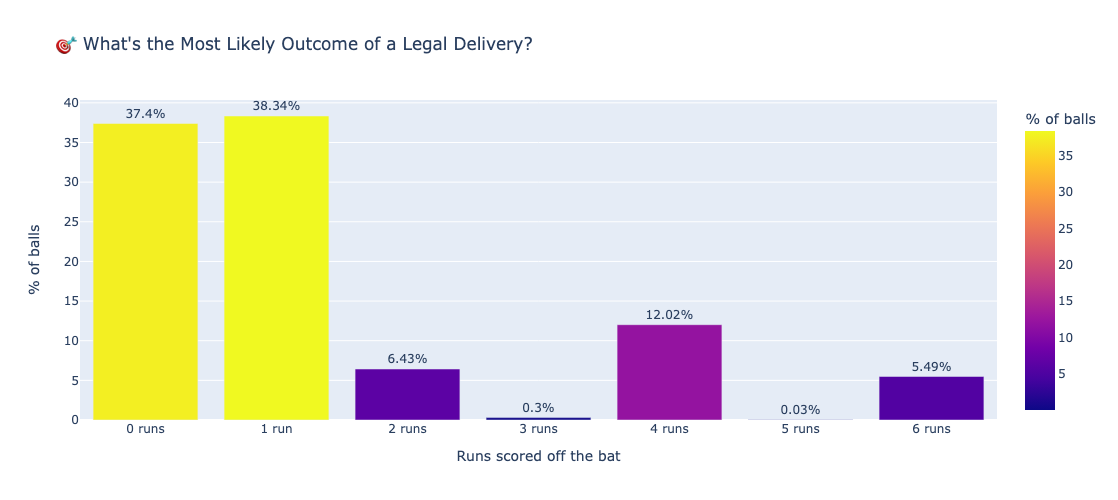


💡 The most common outcome: 1 run — happening 38.34% of the time.
   T20 cricket isn't mostly fours and sixes — it's singles and dots.
   The best batters are the ones who minimise dots and rotate strike.


In [11]:
# Distribution of runs scored on a single legal ball
legal = deliveries[deliveries['is_legal_delivery'] == 1].copy()
scoring = (legal.groupby('runs_off_bat').size().reset_index(name='count')
           .sort_values('runs_off_bat'))
scoring['pct'] = (scoring['count'] / scoring['count'].sum() * 100).round(2)
scoring['label'] = scoring['runs_off_bat'].astype(str) + ' run' + scoring['runs_off_bat'].apply(lambda x: 's' if x != 1 else '')

fig = px.bar(scoring, x='label', y='pct',
             text=scoring['pct'].astype(str) + '%',
             color='pct', color_continuous_scale='Plasma',
             title='🎯 What\'s the Most Likely Outcome of a Legal Delivery?',
             labels={'label': 'Runs scored off the bat', 'pct': '% of balls'})
fig.update_traces(textposition='outside')
fig.update_layout(height=500, showlegend=False)
fig.show()

top = scoring.sort_values('count', ascending=False).iloc[0]
print(f'\n💡 The most common outcome: {top["label"]} — happening {top["pct"]}% of the time.')
print(f'   T20 cricket isn\'t mostly fours and sixes — it\'s singles and dots.')
print(f'   The best batters are the ones who minimise dots and rotate strike.')

## 🎁 BONUS — *The Closest Match Ever*

Save this one as a kicker if there's time.

In [12]:
# Matches won by smallest margins (in runs)
close_runs = matches[matches['winner_runs'].notna()].copy()
close_runs['winner_runs'] = pd.to_numeric(close_runs['winner_runs'], errors='coerce')
close_runs = close_runs.dropna(subset=['winner_runs']).sort_values('winner_runs').head(5)

# Matches won by smallest wicket margins (chase, by very few wickets)
# winner_wickets is the number of wickets the chasing team had remaining (high = thumping win, low = close)
close_wkts = matches[matches['winner_wickets'].notna()].copy()
close_wkts['winner_wickets'] = pd.to_numeric(close_wkts['winner_wickets'], errors='coerce')
close_wkts = close_wkts.dropna(subset=['winner_wickets']).sort_values('winner_wickets').head(5)

print('🥶 CLOSEST MATCHES BY RUNS (smallest margin defending a total):\n')
print(close_runs[['season_year', 'winner', 'winner_runs', 'venue']].to_string(index=False))
print()
print('🥶 CLOSEST CHASES (won with fewest wickets in hand):\n')
print(close_wkts[['season_year', 'winner', 'winner_wickets', 'venue']].to_string(index=False))

🥶 CLOSEST MATCHES BY RUNS (smallest margin defending a total):

 season_year                      winner  winner_runs                                                venue
        2015         Chennai Super Kings          1.0                      MA Chidambaram Stadium, Chepauk
        2019 Royal Challengers Bengaluru          1.0                                M.Chinnaswamy Stadium
        2024         Sunrisers Hyderabad          1.0 Rajiv Gandhi International Stadium, Uppal, Hyderabad
        2019              Mumbai Indians          1.0                   Rajiv Gandhi International Stadium
        2021 Royal Challengers Bengaluru          1.0                     Narendra Modi Stadium, Ahmedabad

🥶 CLOSEST CHASES (won with fewest wickets in hand):

 season_year                winner  winner_wickets                                                              venue
        2015 Kolkata Knight Riders             1.0                                                       Eden Gardens
    

## 🎤 Wrap-up

> *"That's just 10 stats out of literally millions of data points hiding in 290,000 balls bowled. Now imagine what a Machine Learning model can find that we as humans can't even see..."*

**Next:** open `ipl_eda_insights.ipynb` to dive deeper, or jump straight to `ipl_win_predictor.ipynb` to build a model that predicts win probability ball-by-ball.